In [27]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
# Reproducibility seed
SEED = 42
# Load your dataset
# ── Option A: Load from a CSV file ───────────────────────────────────────
df_project = pd.read_csv('finalcombined_sleep_dataset.csv')

# Inspect the dataset
print('Shape:', df_project.shape)
print('\nColumn types:')
print(df_project.dtypes)
print('\nMissing values:')
print(df_project.isnull().sum())
print('\nFirst rows:')
df_project.head()

import time
start_time = time.perf_counter()
print("Notebook timing started")

Shape: (17677, 8)

Column types:
Gender                      object
Age                          int64
Occupation                  object
Sleep Duration             float64
Physical Activity Level      int64
BMI Category                object
Heart Rate                   int64
Sleep Disorder              object
dtype: object

Missing values:
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Physical Activity Level    0
BMI Category               0
Heart Rate                 0
Sleep Disorder             0
dtype: int64

First rows:
Notebook timing started


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# ── Step 1: Identify column types ────────────────────────────────────────
# Adjust these lists to match YOUR dataset's column names
target_col = 'Sleep Disorder' # <-- replace with your target column

num_cols = df_project.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

cat_cols = df_project.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col]

print('Numeric features: ', num_cols)
print('Categorical features:', cat_cols)

# ── Step 2: Define a ColumnTransformer ───────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
cat_cols)
], remainder='drop')

# ── Step 3: Build a full pipeline (preprocessor + model) ─────────────────

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=SEED))
])

Numeric features:  ['Age', 'Sleep Duration', 'Physical Activity Level', 'Heart Rate']
Categorical features: ['Gender', 'Occupation', 'BMI Category']


In [29]:
# Fit and evaluate your data
# ── Prepare X and y (Features and target) ──────────────────────────────────────────────────────
X_proj = df_project.drop(columns=[target_col])
y_proj = df_project[target_col]

# If target is a string label, encode it
le = None
if y_proj.dtype == 'object':
    le = LabelEncoder()
    y_proj = le.fit_transform(y_proj)
    print(le.classes_)


['Healthy' 'Insomnia' 'Sleep Apnea']


In [30]:
# Train/test split
# ── Step 1: 80% train, 20% test ─────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X_proj, y_proj,
    test_size=0.2,
    random_state=SEED,
    stratify=y_proj
)

# Step 2-Hyperparameter tuning
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_tr, y_tr)

# ── Best model ───────────────────────────────────────────────────────────
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)


# ── Final test evaluation ────────────────────────────────────────────────
y_pred = best_model.predict(X_te)

print("\n=== Test Set Performance ===")
print(classification_report(y_te, best_model.predict(X_te)))

print(le.classes_)

from sklearn.model_selection import cross_val_predict
grid.fit(X_tr, y_tr)

best_model = grid.best_estimator_
# ── Cross-validation predictions ────────────────────────────
cv_predictions = cross_val_predict(
    best_model,
    X_tr,
    y_tr,
    cv=cv,
    n_jobs=-1
)

# ── Cross-validation classification report ──────────────────
print("\n=== 10-Fold Cross-Validation Performance ===")

print(classification_report(
    y_tr,
    cv_predictions
))

Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV Score: 0.8850144691399983

=== Test Set Performance ===
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      1000
           1       0.87      0.86      0.86      1270
           2       0.86      0.85      0.86      1266

    accuracy                           0.88      3536
   macro avg       0.88      0.88      0.88      3536
weighted avg       0.88      0.88      0.88      3536

['Healthy' 'Insomnia' 'Sleep Apnea']

=== 10-Fold Cross-Validation Performance ===
              precision    recall  f1-score   support

           0       0.91      0.93      0.92      4000
           1       0.87      0.87      0.87      5078
           2       0.88      0.86      0.87      5063

    accuracy                           0.89     14141
   macro avg       0.89      0.89      0.89     14141
weighted avg       0.88      0.89      0.88

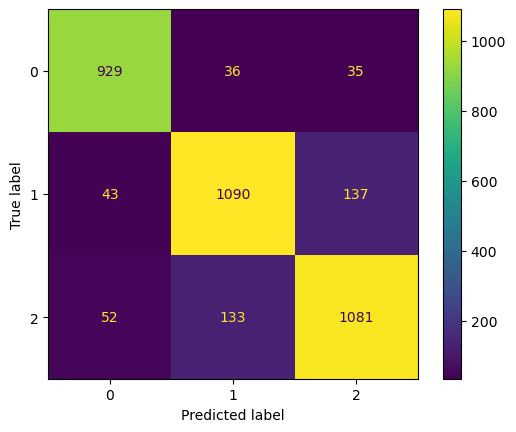

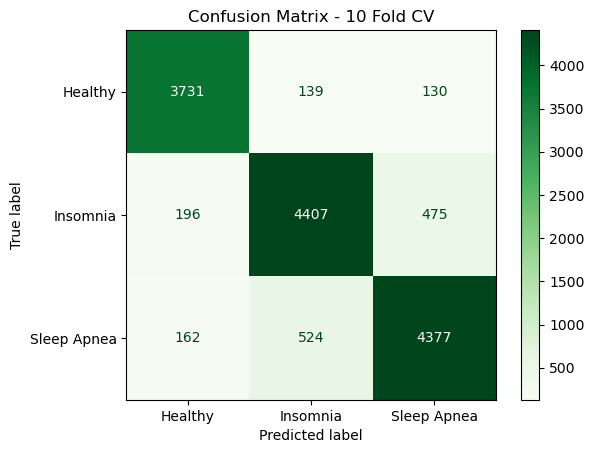

In [31]:
ConfusionMatrixDisplay.from_predictions(
    y_te, 
    best_model.predict(X_te))
plt.show()
ConfusionMatrixDisplay.from_predictions(
    y_tr,
    cv_predictions,
    display_labels=le.classes_,
    cmap='Greens'
)

plt.title("Confusion Matrix - 10 Fold CV")

plt.show()

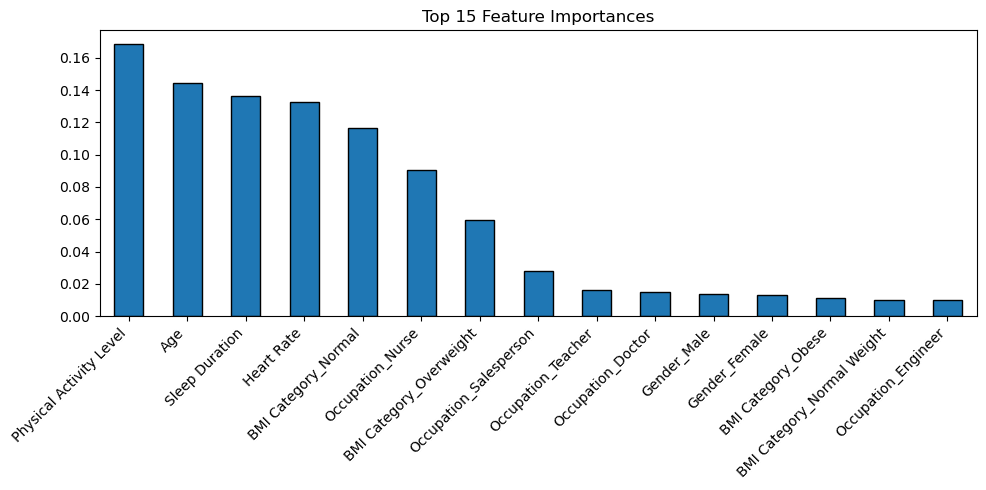

In [32]:
# ── Feature importance ───────────────────────────────────────────────────
rf_model = best_model.named_steps['model']
prep_model = best_model.named_steps['prep']

num_features = num_cols

if len(cat_cols) > 0:
    ohe = prep_model.named_transformers_['cat']
    cat_features = list(ohe.get_feature_names_out(cat_cols))
else:
    cat_features = []

all_features = num_features + cat_features

importances = pd.Series(
    rf_model.feature_importances_,
    index=all_features
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', edgecolor='black')
plt.title('Top 15 Feature Importances')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

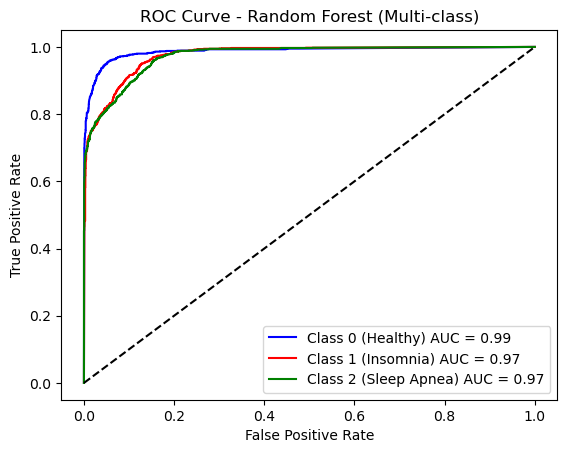

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ── Get predicted probabilities ─────────────────────────────
y_score = best_model.predict_proba(X_te)

# ── Binarize the labels (needed for multi-class ROC) ────────
n_classes = len(le.classes_)
y_test_bin = label_binarize(y_te, classes=range(n_classes))

# ── Compute ROC curve and AUC for each class ────────────────
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# ── Plot ROC curves ─────────────────────────────────────────
plt.figure()

colors = ['blue', 'red', 'green']

for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        label=f'Class {i} ({le.classes_[i]}) AUC = {roc_auc[i]:.2f}'
    )

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Multi-class)')
plt.legend()
plt.show()

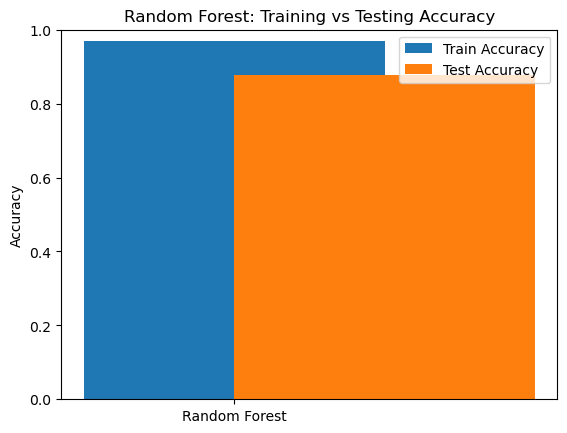

Train Accuracy: 0.9700162647620395
Test Accuracy: 0.8766968325791855


In [34]:
# ── Random Forest accuracy ──────────────────────────────────
rf_train_acc = accuracy_score(y_tr, best_model.predict(X_tr))
rf_test_acc = accuracy_score(y_te, best_model.predict(X_te))


# ── Plot ────────────────────────────────────────────────────
labels = ['Random Forest']
train_acc = [rf_train_acc]
test_acc = [rf_test_acc]

x = range(len(labels))

plt.figure()

plt.bar(x, train_acc, width=0.4, label='Train Accuracy', align='center')
plt.bar(x, test_acc, width=0.4, label='Test Accuracy', align='edge')

plt.xticks(x, labels)
plt.ylim(0, 1)

plt.ylabel('Accuracy')
plt.title('Random Forest: Training vs Testing Accuracy')

plt.legend()
plt.show()


# ── Print values ────────────────────────────────────────────
print("Train Accuracy:", rf_train_acc)
print("Test Accuracy:", rf_test_acc)

In [35]:
# ── Clean hyperparameter results table ──────────────────────
results = pd.DataFrame(grid.cv_results_)

clean_results = results[[
    'param_model__n_estimators',
    'param_model__max_depth',
    'param_model__min_samples_split',
    'mean_test_score'
]]

# Rename columns
clean_results.columns = [
    'n_estimators',
    'max_depth',
    'min_samples_split',
    'CV Accuracy'
]

# Sort best to worst
clean_results = clean_results.sort_values(
    by='CV Accuracy',
    ascending=False
)

print(clean_results.head(10))

    n_estimators max_depth  min_samples_split  CV Accuracy
3            200      None                  5     0.885014
11           200        20                  5     0.884873
10           100        20                  5     0.884519
2            100      None                  5     0.883741
1            200      None                  2     0.883034
9            200        20                  2     0.883034
8            100        20                  2     0.882680
0            100      None                  2     0.881973
5            200        10                  2     0.871507
6            100        10                  5     0.870942


In [36]:
end_time = time.perf_counter()

print(f"Total notebook runtime: {end_time - start_time:.2f} seconds")

Total notebook runtime: 79.41 seconds
